In [1]:
!pip install nba_api pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 12.1 MB/s eta 0:00:00


In [3]:
from nba_api.stats.endpoints import playergamelog
import pandas as pd

gamelog = playergamelog.PlayerGameLog(
    player_id='2544',
    season='2023-24'
)

df = gamelog.get_data_frames()[0]
df.head()

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22023,2544,0022301195,"Apr 14, 2024",LAL @ NOP,W,38,11,20,0.550,0,2,0.000,6,6,1.000,2,9,11,17,5,1,4,0,28,19,1
1,22023,2544,0022301177,"Apr 12, 2024",LAL @ MEM,W,41,13,20,0.650,3,7,0.429,8,11,0.727,2,7,9,5,2,0,8,1,37,-3,1
2,22023,2544,0022301155,"Apr 09, 2024",LAL vs. GSW,L,36,14,22,0.636,1,3,0.333,4,5,0.800,1,6,7,11,2,0,4,0,33,-6,1
3,22023,2544,0022301127,"Apr 06, 2024",LAL vs. CLE,W,36,10,18,0.556,1,5,0.200,3,5,0.600,0,5,5,12,1,1,5,1,24,10,1
4,22023,2544,0022301103,"Apr 03, 2024",LAL @ WAS,W,36,9,18,0.500,0,1,0.000,7,9,0.778,2,5,7,9,3,0,4,2,25,9,1


In [4]:
print("Dataset shape:",df.shape)
print(df.columns)
df.describe()

Dataset shape: (71, 27)
Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE'],
      dtype='object')


,Player_ID,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
count,71.0,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.0
mean,2544.0,35.323944,9.647887,17.873239,0.542239,2.098592,5.112676,0.404592,4.267606,5.690141,0.730859,0.859155,6.436620,7.295775,8.295775,1.253521,0.535211,3.450704,1.098592,25.661972,3.112676,1.0
std,0.0,4.683633,2.624601,3.942188,0.106475,1.604947,2.314854,0.254745,2.413993,2.861526,0.264000,0.975350,3.069353,3.283702,2.820306,1.272998,0.713762,1.628222,1.002211,6.656777,14.238328,0.0
min,2544.0,23.000000,3.000000,10.000000,0.273000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,10.000000,-30.000000,1.0
25%,2544.0,34.500000,7.500000,15.000000,0.474000,1.000000,4.000000,0.291500,2.000000,4.000000,0.636000,0.000000,5.000000,5.000000,6.000000,0.000000,0.000000,2.500000,0.000000,21.000000,-6.000000,1.0
50%,2544.0,36.000000,10.000000,18.000000,0.545000,2.000000,5.000000,0.400000,4.000000,6.000000,0.778000,1.000000,6.000000,7.000000,8.000000,1.000000,0.000000,3.000000,1.000000,25.000000,2.000000,1.0
75%,2544.0,38.000000,12.000000,20.000000,0.600000,3.000000,6.000000,0.500000,6.000000,8.000000,1.000000,1.000000,8.000000,9.000000,9.500000,2.000000,1.000000,4.000000,2.000000,30.000000,13.500000,1.0
max,2544.0,48.000000,15.000000,27.000000,0.833000,9.000000,12.000000,1.000000,10.000000,11.000000,1.000000,5.000000,19.000000,20.000000,17.000000,5.000000,3.000000,8.000000,4.000000,40.000000,36.000000,1.0


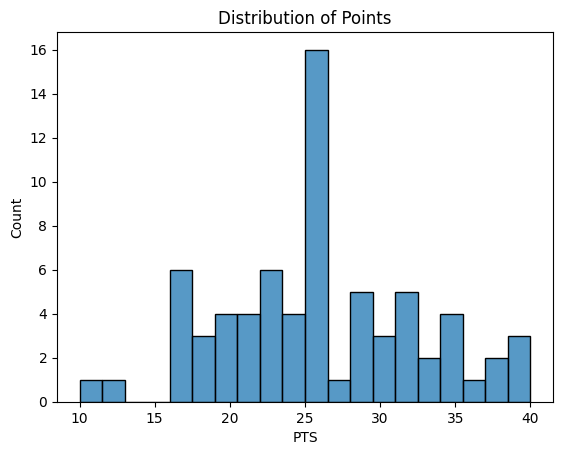

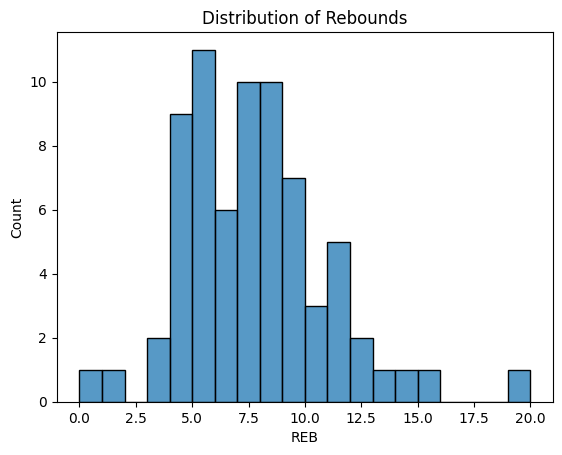

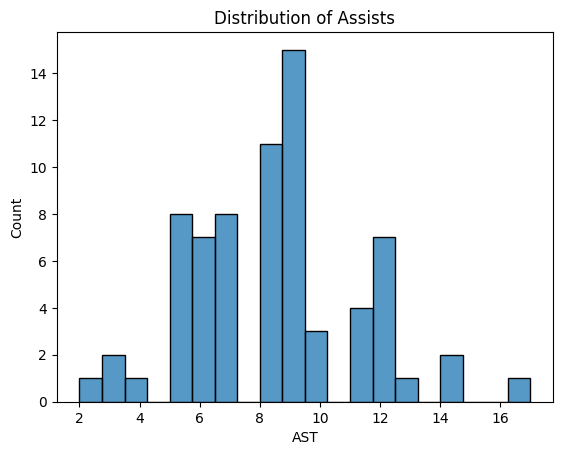

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['PTS'],bins=20)
plt.title("Distribution of Points")
plt.show()

sns.histplot(df['REB'],bins=20)
plt.title("Distribution of Rebounds")
plt.show()

sns.histplot(df['AST'],bins=20)
plt.title("Distribution of Assists")
plt.show()

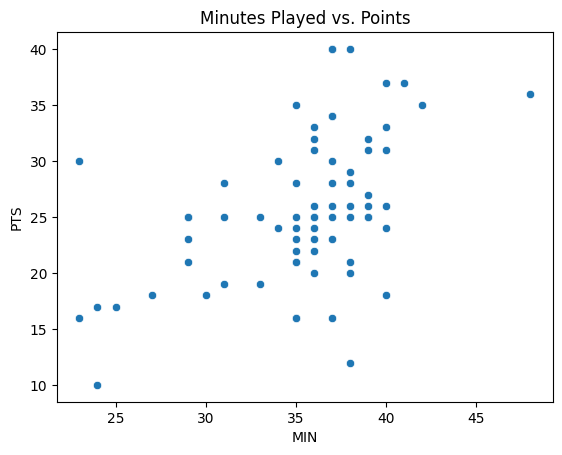

In [6]:
sns.scatterplot(x=df['MIN'],y=df['PTS'])
plt.title("Minutes Played vs. Points")
plt.show()

AttributeError: module 'seaborn' has no attribute 'title'

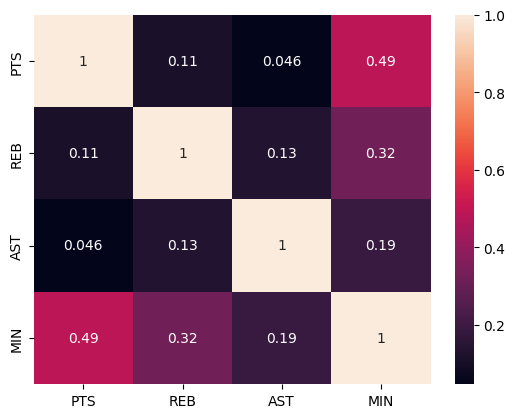

In [7]:
corr = df[['PTS','REB','AST','MIN']].corr()
sns.heatmap(corr,annot=True)
sns.title("Statistical Correlations")
plt.show()